# PCA on data divided by stature

## Import libraries

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sklearn as sk
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

## Read data:

Function that reads all the data from ANSURII:

In [31]:
def read_file():
    dataF = pd.read_csv("ANSURIIFEMALEPublic.csv", encoding='latin-1')
    dataM = pd.read_csv("ANSURIIMALEPublic.csv", encoding='latin-1')

    dataF = dataF.rename(columns= {"SubjectId":"subjectid"}) 
    ansur = pd.concat([dataM, dataF])
    ansur['Gender']=ansur['Gender'].replace(['Male','Female'],['1','0']) #Male =1, Female =0

    ansur['weightkg']=ansur['weightkg']/10
    ansur['shoulderheight']=ansur['acromialheight']-ansur['axillaheight']#upper trunk length
    ansur['middletrunklength']=ansur['chestheight']-ansur['waistheightomphalion']
    ansur['lowetrunklength']=ansur['waistheightomphalion']-ansur['trochanterionheight']
    ansur['thighlink']=ansur['trochanterionheight']-ansur['lateralfemoralepicondyleheight']
    ansur['calflink']=ansur['lateralfemoralepicondyleheight']-ansur['lateralmalleolusheight']
    ansur['forearmlength']=ansur['forearmhandlength']-ansur['handlength']

    return ansur

Function that reads data for females from ANSURII:

In [32]:
def read_file_Female():
    dataF = pd.read_csv("ANSURIIFEMALEPublic.csv", encoding='latin-1')
    dataF = dataF.rename(columns= {"SubjectId":"subjectid"}) 
    dataF['Gender']=dataF['Gender'].replace(['Female'],['0'])

    dataF['weightkg']=dataF['weightkg']/10
    dataF['shoulderheight']=dataF['acromialheight']-dataF['axillaheight']#upper trunk length
    dataF['middletrunklength']=dataF['chestheight']-dataF['waistheightomphalion']
    dataF['lowetrunklength']=dataF['waistheightomphalion']-dataF['trochanterionheight']
    dataF['thighlink']=dataF['trochanterionheight']-dataF['lateralfemoralepicondyleheight']
    dataF['calflink']=dataF['lateralfemoralepicondyleheight']-dataF['lateralmalleolusheight']
    dataF['forearmlength']=dataF['forearmhandlength']-dataF['handlength']

    return dataF

Function that reads data for males from ANSURII:

In [33]:
def read_file_Male():
    dataM = pd.read_csv("ANSURIIMALEPublic.csv", encoding='latin-1')
    dataM['Gender']=dataM['Gender'].replace(['Male'],['1'])

    dataM['weightkg']=dataM['weightkg']/10
    dataM['shoulderheight']=dataM['acromialheight']-dataM['axillaheight']#upper trunk length
    dataM['middletrunklength']=dataM['chestheight']-dataM['waistheightomphalion']
    dataM['lowetrunklength']=dataM['waistheightomphalion']-dataM['trochanterionheight']
    dataM['thighlink']=dataM['trochanterionheight']-dataM['lateralfemoralepicondyleheight']
    dataM['calflink']=dataM['lateralfemoralepicondyleheight']-dataM['lateralmalleolusheight']
    dataM['forearmlength']=dataM['forearmhandlength']-dataM['handlength']

    return dataM

In [34]:
Female = read_file_Female()
Male  = read_file_Male()
ansur = read_file()

## Body sections
Creating body sections form the mesaurments form ansur (sections based on the Hanavan model)

("all" is all the body sections together and not all the mesaurments from ANSURII)

In [ ]:
head= ['bizygomaticbreadth','headbreadth','headcircumference','headlength','mentonsellionlength']

ears = ['earbreadth','earlength','earprotrusion']

upper_trunk = ['shoulderheight', 'chestcircumference','chestdepth','chestbreadth'] #'shoulderlength' interesting?

middle_trunk = ['middletrunklength','waistbreadth','waistcircumference','waistdepth']

lower_trunk = ['hipbreadth','lowetrunklength','buttockcircumference'] #Find a hip crcimference? Use buttock instead?

thigh = ['thighcircumference','thighclearance','thighlink'] # 'lowerthighcircumference' ?

shank = ['anklecircumference','calflink','calfcircumference'] #

foot = ['footbreadthhorizontal','footlength', 'balloffootcircumference']

hand = ['handbreadth','handcircumference','handlength']

upper_arm = ['bicepscircumferenceflexed','acromionradialelength']

forearm = ['forearmcircumferenceflexed','wristcircumference','forearmlength']

neck = ['neckcircumference','neckcircumferencebase']

torso = ['abdominalextensiondepthsitting','bicristalbreadth','chestbreadth','chestcircumference','chestdepth','waistbacklength','waistbreadth','waistcircumference','waistdepth']

all = ['bizygomaticbreadth','headbreadth','headcircumference','headlength','mentonsellionlength','earbreadth','earlength','earprotrusion','shoulderheight', 'chestcircumference','chestdepth','chestbreadth','middletrunklength','waistbreadth','waistcircumference','waistdepth','hipbreadth','lowetrunklength','buttockcircumference','thighcircumference','thighclearance','thighlink','anklecircumference','calflink','calfcircumference','footbreadthhorizontal','footlength', 'balloffootcircumference',
'handbreadth','handcircumference','handlength','bicepscircumferenceflexed','acromionradialelength','forearmcircumferenceflexed','wristcircumference','forearmlength','neckcircumference','neckcircumferencebase','waistbacklength','abdominalextensiondepthsitting','bicristalbreadth']


## Scale
Function that divide each person by its weight and stature:

(Don't think I need this one anymore)

In [36]:
def scale_by_weight_and_stature(data,subset: list, compare: str =None):
    ansur = data.copy()
    df_subset = data[subset].copy()
    for i in range(len(df_subset.index)):
        
        df_subset.iloc[i] = df_subset.iloc[i]/(data.iloc[i]['stature']*data.iloc[i]['weightkg'])
        #print(df_subset.iloc[i].values[0])
    df_subset['Gender']=ansur['Gender']

    return df_subset

In [37]:
ansur_scaled=scale_by_weight_and_stature(ansur,head)

C:\Users\augus\AppData\Local\Temp\ipykernel_38828\941716621.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.000981042392085337' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_subset.iloc[i] = df_subset.iloc[i]/(data.iloc[i]['stature']*data.iloc[i]['weightkg'])
C:\Users\augus\AppData\Local\Temp\ipykernel_38828\941716621.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.0010363123860056376' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_subset.iloc[i] = df_subset.iloc[i]/(data.iloc[i]['stature']*data.iloc[i]['weightkg'])
C:\Users\augus\AppData\Local\Temp\ipykernel_38828\941716621.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.004027800806

How to scale if i do not want to have the subset here already? I want to choose subset later

In [38]:
def scale_by_weight_and_stature_all(data, compare: str = None):
    ansur = data.copy()
    # Behåll endast numeriska kolumner (exkludera 'stature' som används som nämnare)
    numeric_cols = ansur.select_dtypes(include='number').columns.drop('stature','weightkg')
    
    df_ansur = ansur[numeric_cols]
    stature = ansur['stature']
    weightkg = ansur['weightkg']
    # Dividera varje kolumn med respektive rad i stature
    df_ansur = df_ansur.div(stature, axis=0)
    df_ansur = df_ansur.div(weightkg, axis=0)
    
    return df_ansur


In [39]:
ansur_scaled_all=scale_by_weight_and_stature_all(ansur)

Scaling one more time

Now removing mean from male and female separatly

In [40]:
def create_subset(data, subset: list):
    #ansur = read_file()
    df_subset= data[subset].copy()
    #df_subset['Gender']=data['Gender']
    df_subset.loc[:, 'Gender'] = data['Gender']
    return df_subset

In [41]:
def scale_mean(data, subset:list):
    subset = create_subset(data,subset)
    scaler = StandardScaler(with_mean=True, with_std=False)
    centered = scaler.fit_transform(subset)
    df_centered = pd.DataFrame(centered, columns=subset.keys())
    return df_centered

In [42]:
def male_and_female_no_mean(subset: list, compare: str =None):
    Male = read_file_Male()
    Female = read_file_Female()
    ansur1 = read_file()

    male_n_m= scale_mean(Male,subset)
    flemale_n_m = scale_mean(Female,subset)
    ansur = pd.concat([male_n_m, flemale_n_m])
    ansur_df = pd.DataFrame(ansur)
    ansur_df['Gender']=ansur1['Gender'].replace(['Male','Female'],['1','0']) #Male =1, Female =0
    if compare == 'Ethnicity':
        ansur_df['Ethnicity'] = ansur1['Ethnicity']
    elif compare == 'Component':
        ansur_df['Component']=ansur1['Component']
    ansur_df['stature']=ansur1['stature']
    ansur_df['weightkg']=ansur1['weightkg']

    return ansur_df

In [43]:
ansur_no_mean =male_and_female_no_mean(head)

Scaling both with weight and stature and centering by removing mean for male and female separatly:

In [44]:
dubble_scaled = scale_by_weight_and_stature_all(ansur_no_mean)

## Plots

### Scree-plot:

Shows the procentages of variance explained by the different PCs @(PCA_review_reset)

In [45]:
def scree_plot(data, subset: list ,subset_name: str):
    ansur = data
    #df_subset=create_subset(subset,group)
    df_subset= ansur[subset]
    pca = PCA(n_components=len(df_subset.keys()))
    principal_components = pca.fit_transform(df_subset)

    per_var = np.round(pca.explained_variance_ratio_* 100, decimals=1)
    labels = ['PC' + str(x) for x in range(1, len(per_var)+1)]
    #df = pd.DataFrame(data=d)
    df_per_var = pd.DataFrame(data=per_var).T
    df_per_var.columns=labels
    print(df_per_var)
    
    per = 0
    for i in range(len(per_var)):
        per += per_var[i]
        if per >= 95:
            print('Interesting PCs to get 95%: '+ str(labels[:i+1]))
            break
    
    plt.bar(x=range(1,len(per_var)+1), height=per_var, tick_label=labels)
    plt.ylabel('Percentage of Explained Variance')
    plt.xlabel('Principal Component')
    plt.title('Scree Plot: '+subset_name)
    plt.xticks(rotation=90)
    plt.show()


    PC1  PC2  PC3  PC4  PC5  PC6  PC7  PC8  PC9  PC10  ...  PC32  PC33  PC34  \
0  90.9  3.6  1.9  0.8  0.5  0.4  0.3  0.2  0.2   0.2  ...   0.0   0.0   0.0   

   PC35  PC36  PC37  PC38  PC39  PC40  PC41  
0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  

[1 rows x 41 columns]
Interesting PCs to get 95%: ['PC1', 'PC2', 'PC3']


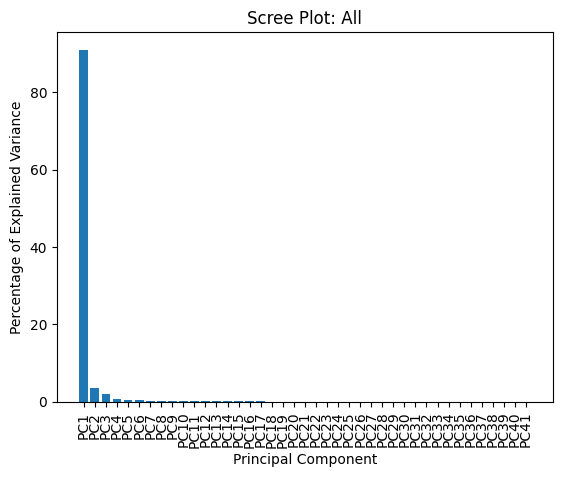

In [109]:
scree_plot(ansur_scaled_all,all,'All')

### Pairplot:

Shows the correlation between all measurements. The genders are represented by different colors

In [47]:
def Pairplot(data_scaled):
    sns.pairplot(data_scaled, hue="Gender")

In [48]:
def Pairplot(data,data_scaled):
    ansur = data
    ansur_scaled = data_scaled

    ansur_scaled['Gender']=ansur['Gender']

    sns.pairplot(data_scaled, hue="Gender")

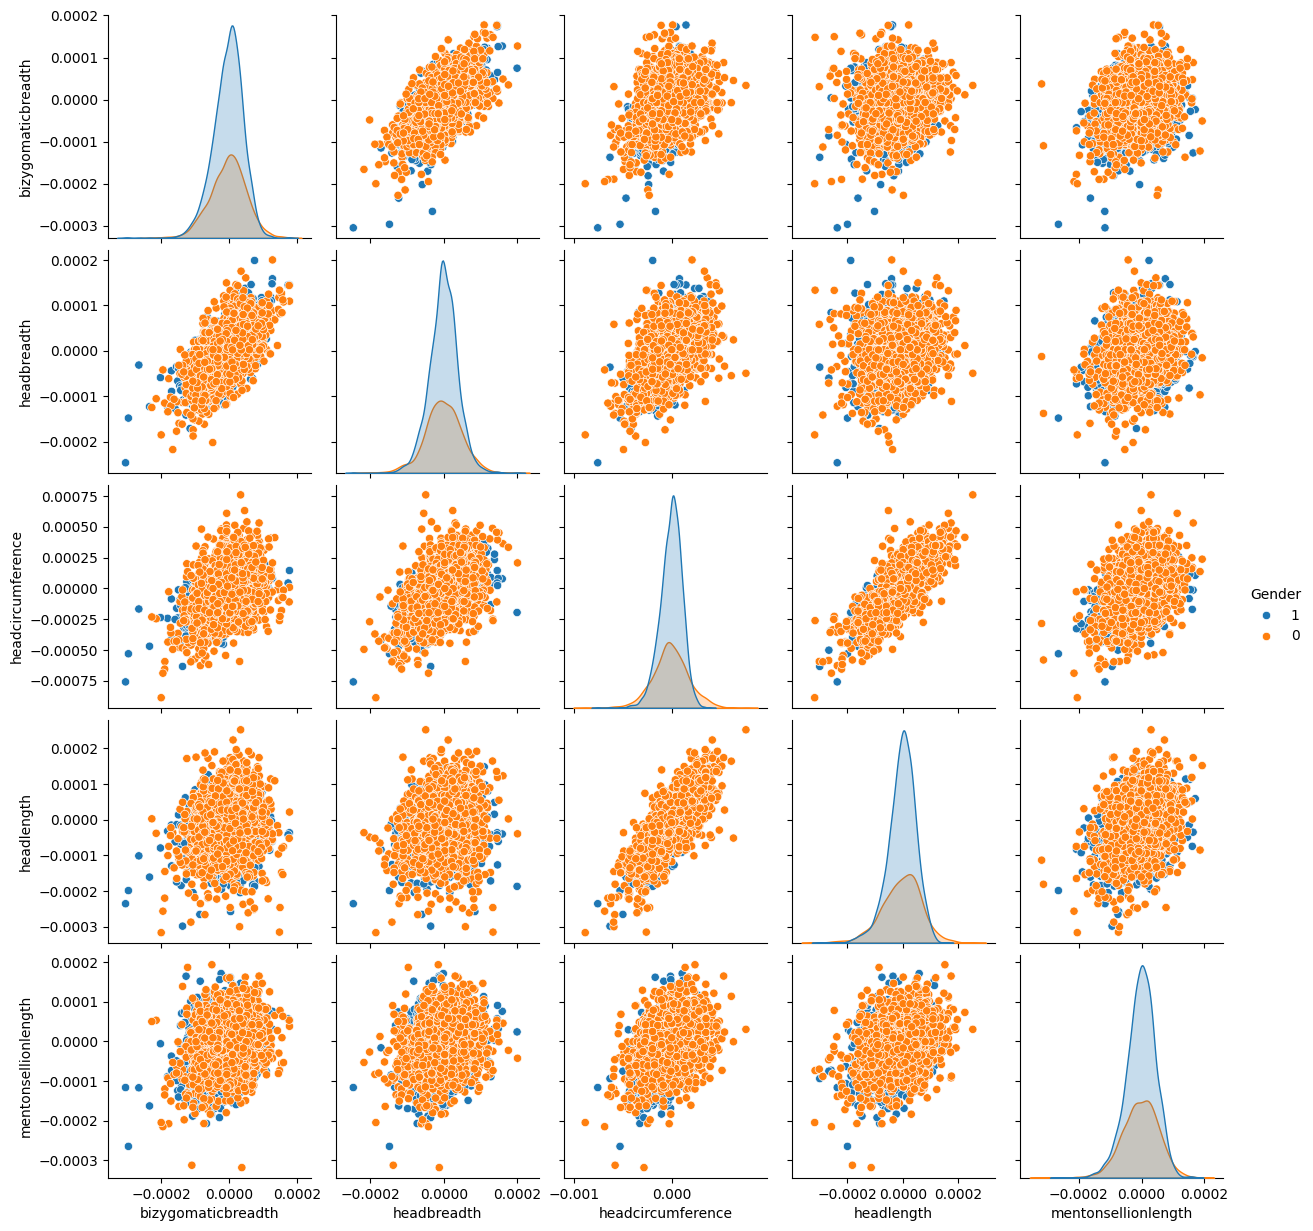

In [49]:
Pairplot(ansur,dubble_scaled[head])

### 2D-plot:

Shows the correlation between the two first PCs

In [50]:
def PC2_plot(data,data_scaled,subset: list,subsetname: str, compare: str,  ax =None ):
    #df_subset =male_and_female_no_mean(subset)
    df_subset = data_scaled[subset]
    ansur_c = data.copy()
    #data_name = get_var_name(data)[0]

    # PCA med 2 komponenter
    pca = PCA(n_components=len(df_subset.keys()))# =2,whiten=True)
    X_pca = pca.fit_transform(df_subset) # fit--> Beräknar PCA baserat på df_subset, transform --> Transformerar datan till de nya PC-axlarna
    

    # Skapa en DataFrame för plottning
    #df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
    df_pca = pd.DataFrame(X_pca, columns = [f'PC{i+1}' for i in range(len(df_subset.keys()))])
    #df_pca_subset.columns = [f'PC{i+1}' for i in range(len(df_subset.keys()))]
    ansur_c = ansur_c.reset_index(drop=True) # Only needed when subset?
    

    #df_pca['Gender']=ansur_c['Gender'] #SHOULD I DO LIKE THIS??????????
    df_pca[compare]=ansur_c[compare]
   

    per_var = np.round(pca.explained_variance_ratio_* 100, decimals=1)

    if ax == None:
    # Plotta PC1 vs PC2 färglagd efter kön
        plt.figure(figsize=(8,6))
        sns.scatterplot(x=df_pca["PC1"], y=df_pca["PC2"], hue=df_pca[compare], alpha=0.6, palette="coolwarm", ax=ax)
        plt.xlabel('PC1 - {0}%'.format(per_var[0]))
        plt.ylabel('PC2 - {0}%'.format(per_var[1]))
        plt.title("PCA: Difference between "+ compare +' - ' +subsetname)#+' - ' +data_name)
        plt.axhline(0, color='gray', linestyle='--')
        plt.axvline(0, color='gray', linestyle='--')
        plt.legend(title= compare , bbox_to_anchor=(1, 1))

        plt.show()

    else: 
        sns.scatterplot(x=df_pca["PC1"], y=df_pca["PC2"], hue=df_pca[compare], alpha=0.6, palette="coolwarm", ax=ax)
        ax.set_xlabel('PC1 - {0}%'.format(per_var[0]))
        ax.set_ylabel('PC2 - {0}%'.format(per_var[1]))
        ax.set_title("PCA: Difference between " + compare + ' - ' + subsetname)#+' - ' +data_name)
        ax.axhline(0, color='gray', linestyle='--')
        ax.axvline(0, color='gray', linestyle='--')
        ax.legend(title=compare, loc="upper left", bbox_to_anchor=(1, 1))

Plot - divided by both weight and stature

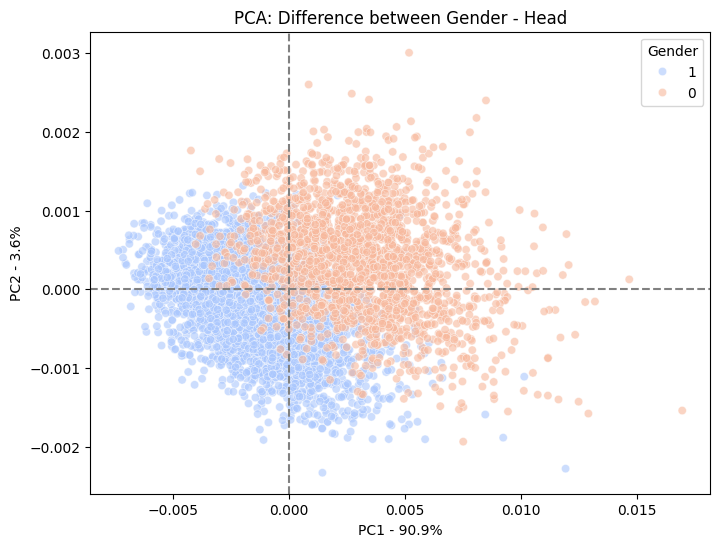

In [51]:
PC2_plot(ansur,ansur_scaled_all,all,'Head','Gender')

Plot - divided by weight and stature and centered:

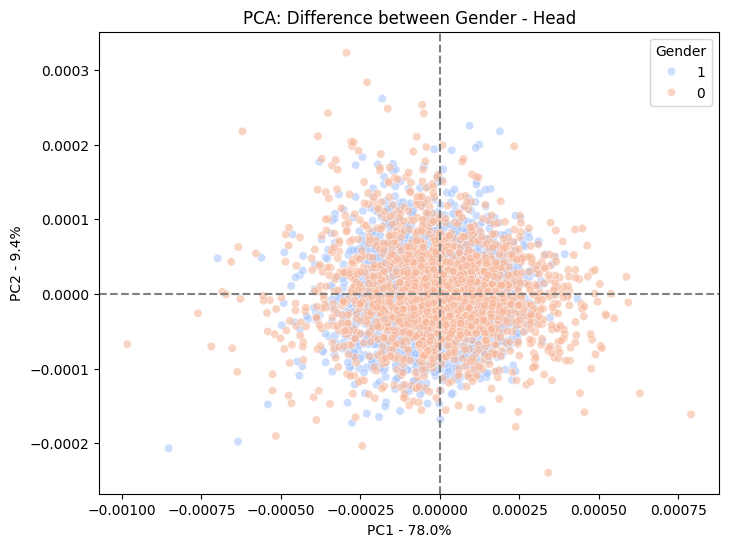

In [52]:
PC2_plot(ansur,dubble_scaled,head,'Head','Gender')

### Biplot:

Shows the 2D-plot with arrows representing the variables

In [ ]:
def PC2_plot_biplot(data,data_scaled,subset: list,subsetname: str,compare: str, ax = None ): #
    #if ax is None:
     #   ax = plt.gca()  # Använd aktuell axel om ingen ges
    ansur = data
    ansur_c=ansur.copy()
    df_subset = data_scaled[subset]
    #loadings = loadings_function(data,subset)

    # PCA med 2 komponenter
    pca = PCA(n_components=len(df_subset.keys()))#2)#,whiten=True)
    X_pca = pca.fit_transform(df_subset) # fit--> Beräknar PCA baserat på df_subset, transform --> Transformerar datan till de nya PC-axlarna
    
    # Skapa en DataFrame för plottning
    df_pca = pd.DataFrame(X_pca, columns= [f'PC{i+1}' for i in range(len(df_subset.keys()))])
    ansur_c = ansur_c.reset_index(drop=True) # Only needed when subset?
    df_pca[compare]=ansur_c[compare]

    
    loadings = pca.components_.T
    per_var = np.round(pca.explained_variance_ratio_* 100, decimals=1)
    # Beräkna totala laddningar

    # Välj de 10 största laddningarna
    #top_10_indices = np.argsort(total_loadings)[-10:]
    loading_lengths = np.linalg.norm(loadings[:, :2], axis=1)  # L2-norm (dvs. längden på pilen)

    # Indices till de 10 längsta pilarna
    top_10_indices = np.argsort(loading_lengths)[-10:]  


    # Plotta PC1 vs PC2 färglagd efter kön
    #plt.figure(figsize=(8,6))

    if ax == None:
        plt.figure(figsize=(12,10))
        sns.scatterplot(x=df_pca["PC1"], y=df_pca["PC2"], hue=df_pca[compare], alpha=0.6, palette="coolwarm")
        plt.xlabel('PC1 - {0}%'.format(per_var[0]))
        plt.ylabel('PC2 - {0}%'.format(per_var[1]))
        plt.title("PCA: Difference between "+ compare +' - ' +subsetname)
        plt.axhline(0, color='gray', linestyle='--')
        plt.axvline(0, color='gray', linestyle='--')
        #loadings = df_pca.components_.T  # PCA-laddningar
        #loadings = pca.components_

        if subsetname == 'All':
            #for i, var in enumerate(df_subset.columns):
             #   plt.arrow(0, 0, loadings[i, 0]*500, loadings[i, 1]*500, color='red', alpha=0.5)
              #  plt.text(loadings[i, 0]*500, loadings[i, 1]*500, var, color='red')
            for i in top_10_indices:
                plt.arrow(0, 0, loadings[i, 0]*0.006, loadings[i, 1]*0.006, color='red', alpha=0.5, width=0.00002)
                plt.text(loadings[i, 0]*0.006+0.0002, loadings[i, 1]*0.006, df_subset.columns[i], color='red') 
        else:
            for i, var in enumerate(df_subset.columns):
                plt.arrow(0, 0, loadings[i, 0]*0.005, loadings[i, 1]*0.005, color='red', alpha=0.5, width=0.000002)
                plt.text(loadings[i, 0]*0.005, loadings[i, 1]*0.005, var, color='red')
        
        plt.legend(title= compare,loc="upper left", bbox_to_anchor=(1, 1))
        plt.grid()
        plt.show()
    
    else: 
        sns.scatterplot(x=df_pca["PC1"], y=df_pca["PC2"], hue=df_pca[compare], alpha=0.6, palette="coolwarm",ax=ax)
        ax.set_xlabel('PC1 - {0}%'.format(per_var[0]))
        ax.set_ylabel('PC2 - {0}%'.format(per_var[1]))
        ax.set_title("PCA: Difference between "+ compare +' - ' +subsetname)
        ax.axhline(0, color='gray', linestyle='--')
        ax.axvline(0, color='gray', linestyle='--')
        #loadings = df_pca.components_.T  # PCA-laddningar
        loadings = pca.components_
        if subsetname == 'All':
            for i, var in enumerate(df_subset.columns):
                ax.arrow(0, 0, loadings[i, 0]*0.003, loadings[i, 1]*0.003, color='red', alpha=0.5,width=0.00005)
                ax.text(loadings[i, 0]*0.003, loadings[i, 1]*0.003, var, color='red')
        else:
            for i, var in enumerate(df_subset.columns):
                #ax.arrow(0, 0, loadings[i, 0]*df_subset[var].mean(), loadings[i, 1]*df_subset[var].mean(), color='red', alpha=0.5)
                #ax.text(loadings[i, 0]*df_subset[var].mean(), loadings[i, 1]*df_subset[var].mean(), var, color='red')
                ax.arrow(0, 0, loadings[i, 0]*0.0003, loadings[i, 1]*0.0003, color='red', alpha=0.5,width=0.00001)
                ax.text(laodings[i, 0]*0.0003, loadings[i, 1]*0.0003, var, color='red')
                    
            ax.legend(title= compare,loc="upper left", bbox_to_anchor=(1, 1))


[[ 0.06665362 -0.05033225 -0.01870985 ...  0.1120836  -0.02056957
   0.01236431]
 [ 0.07772818 -0.06048536 -0.01048702 ... -0.16964446 -0.02152834
  -0.0303852 ]
 [ 0.29543662 -0.21613711  0.05750484 ...  0.03474676  0.00882529
   0.01290409]
 ...
 [ 0.184872   -0.19653221 -0.13802584 ... -0.00307717 -0.00031747
  -0.00047617]
 [ 0.07623578  0.16456701 -0.12968946 ...  0.00418182 -0.01023696
  -0.0026435 ]
 [ 0.12953058  0.00037602  0.04500893 ... -0.00459994 -0.00961532
  -0.00178078]]


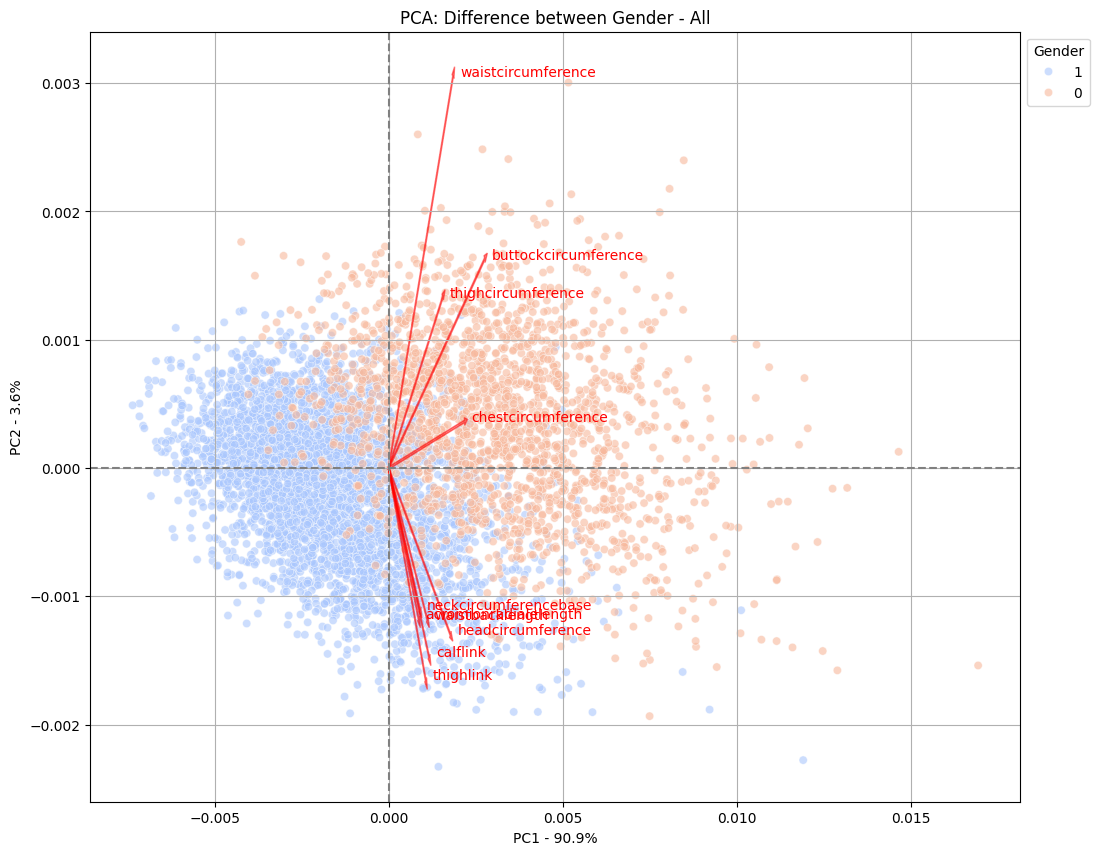

In [137]:
PC2_plot_biplot(ansur,ansur_scaled_all,all,'All','Gender')

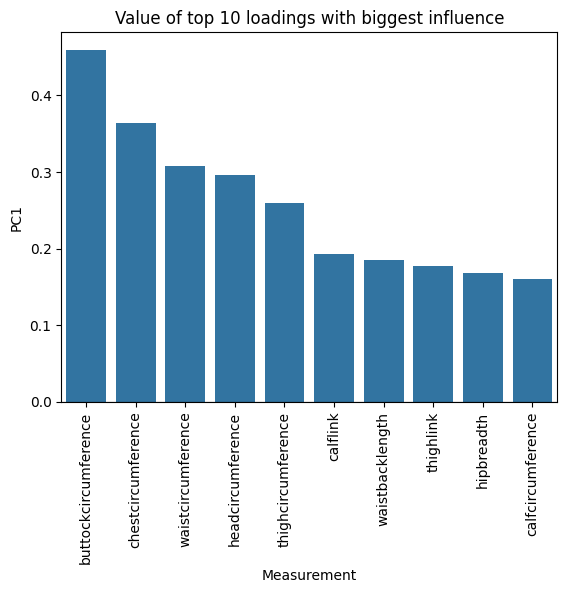

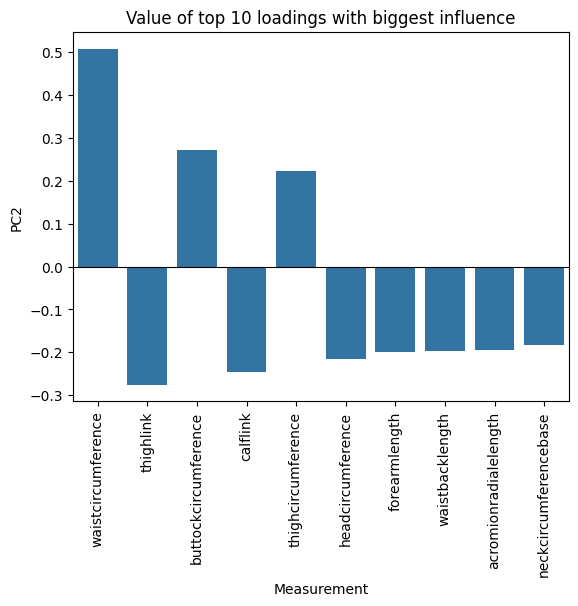

In [108]:
plot_loadings(ansur_scaled_all,all,'All',1)
plot_loadings(ansur_scaled_all,all,'All',2)


### Loadings:

Function thet gives the loading for the PCs from the PCA

In [55]:
def loadings_function(data, subset: list):
    ansur = data.copy()
    df_subset = ansur[subset]
    
    #Gives the PCA for all the measurments in the subset for the data
    pca_subset = PCA(n_components=len(df_subset.keys()))
    principal_components = pca_subset.fit_transform(df_subset)

    # Create a DataFrame with the information of the loadings
    df_loadings_subset = pd.DataFrame(pca_subset.components_, columns=df_subset.keys(), index=[f'PC{i+1}' for i in range(len(df_subset.keys()))])
    return df_loadings_subset

Shows a barplot of the top 10 most influencing loadings and their values

Here "number" is number of the PC that will be plotted

In [56]:
def plot_loadings(data,subset: list,subsetname:str, number:int,ax=None):
    df_loadings = loadings_function(data,subset)
    df_loadings_val=df_loadings.T

    #top_10_values = df_loadings_val.nlargest(10, f'PC{number}')
    top_10_values = df_loadings_val.loc[df_loadings_val[f'PC{number}'].abs().nlargest(10).index]


    #if ax == None: 
    if ax is None:
        #sns.barplot(x=df_loadings.keys(), y=df_loadings_val[f'PC{number}'])
        sns.barplot(x=top_10_values.T.keys(), y=top_10_values[f'PC{number}'])
      
        plt.title(f'Value of top {len(top_10_values.T.keys())} loadings with biggest influence')
        plt.ylabel(f'PC{number}')
        plt.xlabel('Measurement')
        plt.axhline(0, color='black', linewidth=0.8)  # Lägg till en linje vid y=0
        plt.xticks(rotation=90)

        plt.show()
    else:
        sns.barplot(x=top_10_values.T.keys(), y=top_10_values[f'PC{number}'],ax=ax)
        # Anpassa plotten
        ax.set_title('Value of top 10 loadings with biggest influence'+ '-' + subsetname)
        ax.set_ylabel(f'PC{number}')
        ax.set_xlabel('Measurement')
        ax.axhline(0, color='black', linewidth=0.8)  # Lägg till en linje vid y=0
        #ax.set_xticks(range(len(df_loadings.keys())))
        #ax.set_xticklabels(ax,rotation=90)


Plotting the loadings for PC1:

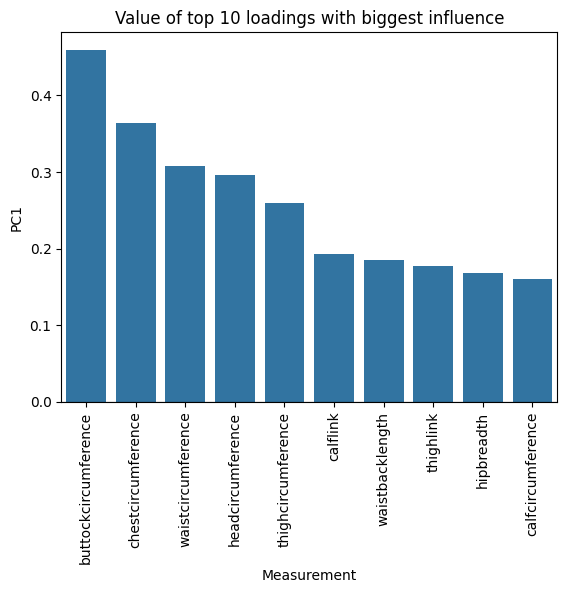

In [60]:
plot_loadings(ansur_scaled_all,all,'All',1)